# K-средних и K-средних++ (K-means, K-means++)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**K-средних** (англ. *K-means*, читается «кей-минс», дословно — «K средних») — это один из самых известных алгоритмов **кластеризации** (то есть разбиения объектов на группы без заранее заданных меток классов). Алгоритм делит данные на **K** кластеров так, чтобы каждый объект принадлежал тому кластеру, чей **центр** (центроид, англ. *centroid* — «центральная точка») ближе всего. Работает алгоритм итеративно: (1) выбираются начальные K центров, (2) каждый объект относится к ближайшему центру, (3) центр каждого кластера пересчитывается как среднее его объектов, шаги (2) и (3) повторяются до стабилизации. Слабое место классического K-средних — **случайная инициализация**: если начальные центры выбраны неудачно, алгоритм может сойтись к плохому решению. Чтобы это исправить, придумали улучшенный вариант — **K-средних++** (*K-means++*): он выбирает начальные центры не случайно, а «умно» — так, чтобы они оказались как можно дальше друг от друга. На практике это даёт более устойчивые и качественные результаты. В этом ноутбуке сравниваются обе стратегии инициализации на встроенном датасете `Wine` из библиотеки scikit-learn.

## 2. Блок с используемыми библиотеками

Короткие пояснения к англоязычным названиям:
- **numpy** — численные операции с массивами.
- **pandas** — таблицы (DataFrame, читается «дата-фрейм») и удобная работа с данными.
- **matplotlib** — базовая библиотека графиков.
- **seaborn** (читается «сиборн») — красивые статистические графики поверх matplotlib.
- **scikit-learn** (читается «сайкит-лёрн») — библиотека машинного обучения.
- **KMeans** — сам алгоритм K-средних из scikit-learn. Параметр `init` задаёт способ инициализации: `'random'` — обычная случайная, `'k-means++'` — умная инициализация.
- **StandardScaler** — стандартизатор: приводит признаки к «одному масштабу» (среднее 0, разброс 1). Для K-средних это обязательно, так как алгоритм опирается на расстояния.
- **PCA** (*Principal Component Analysis*, метод главных компонент) — способ сжать многомерные данные до 2 измерений для визуализации на плоскости.

In [1]:
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера используем встроенный набор данных **Wine** (в переводе — «Вино») из библиотеки scikit-learn. Это 178 образцов вина, каждый описан 13 числовыми химическими показателями (содержание алкоголя, кислот, магния, интенсивность цвета и т.д.). В оригинале датасет — задача **классификации** на три сорта винограда (`class_0`, `class_1`, `class_2`), но нас интересует **кластеризация**: мы попросим K-средних самостоятельно найти 3 группы в данных, **не показывая** ему правильные ответы. Правильные метки будем использовать только для оценки качества кластеризации в конце. Датасет встроен в scikit-learn — ничего скачивать не нужно, ноутбук сразу запускается в Google Colab.

In [2]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y_true = pd.Series(data.target, name="target")       # истинные метки — только для оценки
target_names = list(data.target_names)                # ['class_0', 'class_1', 'class_2']

df = X.copy()
df["target"] = y_true

print("Размерность датасета (строк, столбцов):", df.shape)
print("Имена настоящих классов:", target_names)
print("\nРаспределение настоящих классов (сколько объектов каждого сорта):")
print(y_true.value_counts().sort_index())

print("\nПервые 5 строк датасета:")
display(df.head(5))

print("\nОписательная статистика по признакам (первые 10):")
display(df.describe().T.head(10))

Размерность датасета (строк, столбцов): (178, 14)
Имена настоящих классов: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Распределение настоящих классов (сколько объектов каждого сорта):
target
0    59
1    71
2    48
Name: count, dtype: int64

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Описательная статистика по признакам (первые 10):


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Пояснение к таблицам:** каждая строка — одно вино, каждый столбец — числовой признак (`alcohol` — содержание алкоголя, `malic_acid` — яблочная кислота, `ash` — зола, `magnesium` — магний и т.д.). Столбец `target` — настоящий сорт, алгоритму его показывать **не будем** — наша задача проверить, сможет ли K-средних сам найти эти три группы.

## 4. Блок с предварительной обработкой датасета

Что делаем:
1. Проверяем **пропуски** (пустые значения) и **дубликаты** (повторяющиеся строки).
2. Выполняем **стандартизацию** признаков (`StandardScaler` — приводит каждый числовой столбец к нулевому среднему и единичному разбросу). Для K-средних это **обязательно**, потому что алгоритм опирается на расстояния. Если один признак измеряется в сотнях (например, `proline`), а другой — в единицах (например, `hue`), то расстояние «перекосится» в сторону крупного признака, и кластеризация будет фактически строиться только по нему.

In [3]:
# 1) Пропуски
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски по каждому столбцу (если везде 0 — пропусков нет):")
print(missing.head(10))

# 2) Дубликаты
dup_count = df.duplicated().sum()
print("\nКоличество полностью совпадающих строк (дубликатов):", dup_count)

# 3) Стандартизация признаков (X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nРазмерность X после стандартизации:", X_scaled.shape)
print("\nСредние значения признаков после стандартизации (должны быть ≈ 0):")
print(X_scaled.mean().round(3).head(13))
print("\nСтандартные отклонения признаков (должны быть ≈ 1):")
print(X_scaled.std().round(3).head(13))

print("\nПервые строки X после стандартизации:")
display(X_scaled.head(5))

Пропуски по каждому столбцу (если везде 0 — пропусков нет):
alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
dtype: int64

Количество полностью совпадающих строк (дубликатов): 0

Размерность X после стандартизации: (178, 13)

Средние значения признаков после стандартизации (должны быть ≈ 0):
alcohol                        -0.0
malic_acid                     -0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                     -0.0
nonflavanoid_phenols            0.0
proanthocyanins                -0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Стандартные 

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 5. Блок с тепловой картой

Тепловая карта (англ. *heatmap* — «карта тепла») показывает **корреляции** — насколько сильно признаки связаны друг с другом. Значения близки к **+1** — сильная прямая связь (растёт один — растёт другой), к **−1** — сильная обратная связь, к **0** — связи почти нет. Для кластеризации это полезно: если два признака сильно скоррелированы, они вносят в расстояние «одно и то же» дважды. Также добавим столбец `target` (истинный класс) — так можно заранее увидеть, какие признаки лучше всего разделяют сорта вина.

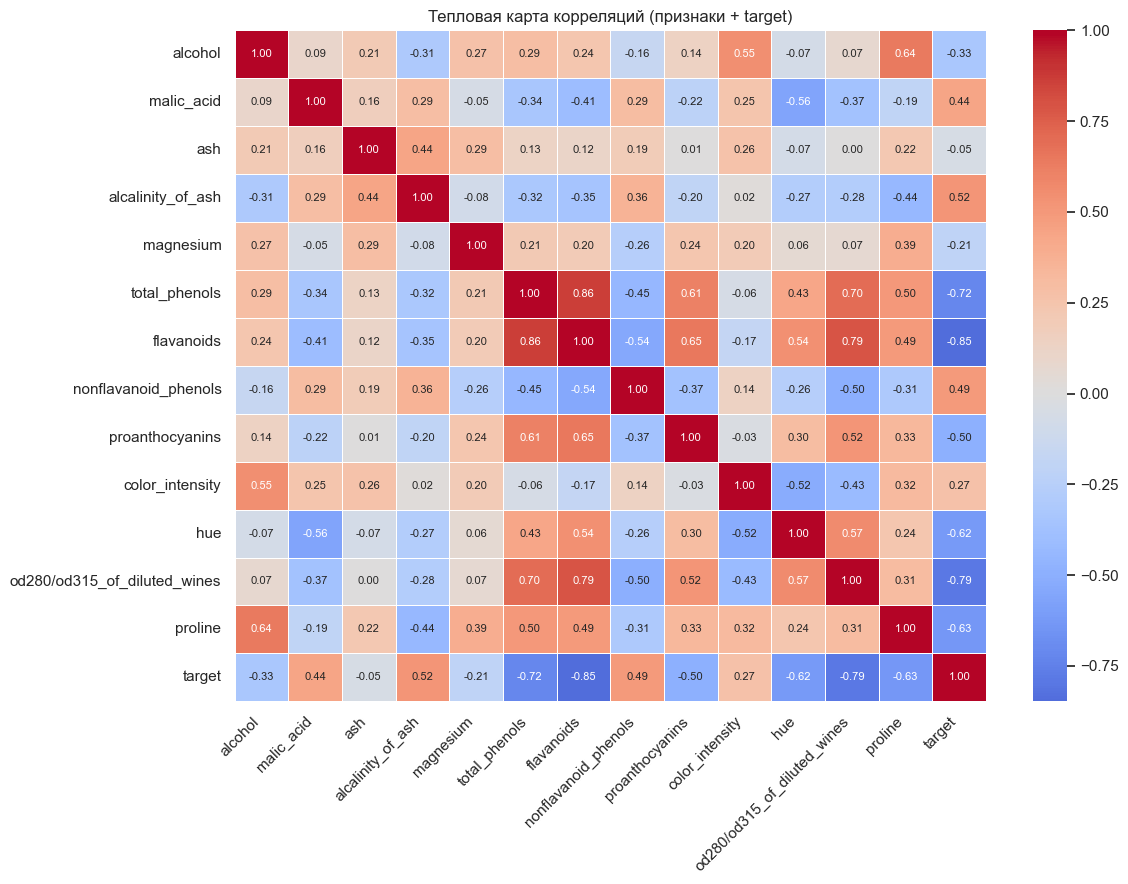

Корреляции признаков с target (по убыванию модуля) — чем больше по модулю, тем сильнее признак различает сорта:
flavanoids                     -0.847
od280/od315_of_diluted_wines   -0.788
total_phenols                  -0.719
proline                        -0.634
hue                            -0.617
alcalinity_of_ash               0.518
proanthocyanins                -0.499
nonflavanoid_phenols            0.489
malic_acid                      0.438
alcohol                        -0.328
color_intensity                 0.266
magnesium                      -0.209
ash                            -0.050
Name: target, dtype: float64


In [4]:
df_scaled = X_scaled.copy()
df_scaled["target"] = y_true.values

corr = df_scaled.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title("Тепловая карта корреляций (признаки + target)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Корреляции признаков с target (по убыванию модуля) — чем больше по модулю, тем сильнее признак"
      " различает сорта:")
target_corr = corr["target"].drop("target")
print(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).round(3))

## 6. Блок с обучением модели

Обучаем **два варианта K-средних** на стандартизованных данных:
- `init='random'` — классический K-средних со случайной инициализацией центров.
- `init='k-means++'` — умная инициализация (K-средних++).

Ключевые параметры:
- **n_clusters** — сколько кластеров искать (здесь ставим 3, т.к. из задачи известно, что сортов три; дополнительно проверим это **методом локтя** ниже);
- **n_init** — сколько раз алгоритм перезапускается с разными начальными центрами (возвращается лучший результат). Для честного сравнения ставим `n_init=10` для обоих вариантов.

После обучения смотрим на **inertia** (англ. «инерция») — сумму квадратов расстояний от каждого объекта до центра его кластера. Чем меньше, тем «плотнее» кластеры. Именно эту величину K-средних минимизирует.

In [5]:
# Классический K-средних (случайная инициализация)
km_random = KMeans(
    n_clusters=3,
    init="random",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE,
)
km_random.fit(X_scaled)

# K-средних++ (умная инициализация)
km_pp = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE,
)
km_pp.fit(X_scaled)

print("=== K-средних (init='random') ===")
print(f"Inertia (сумма квадратов расстояний до центров): {km_random.inertia_:.3f}")
print(f"Число итераций до сходимости:                     {km_random.n_iter_}")

print("\n=== K-средних++ (init='k-means++') ===")
print(f"Inertia (сумма квадратов расстояний до центров): {km_pp.inertia_:.3f}")
print(f"Число итераций до сходимости:                     {km_pp.n_iter_}")

print("\nКоординаты центров кластеров (K-средних++), первые 5 признаков:")
centers_pp = pd.DataFrame(
    km_pp.cluster_centers_,
    columns=X.columns,
    index=[f"центр кластера {i}" for i in range(3)],
)
display(centers_pp.iloc[:, :5].round(3))

=== K-средних (init='random') ===
Inertia (сумма квадратов расстояний до центров): 1277.928
Число итераций до сходимости:                     7

=== K-средних++ (init='k-means++') ===
Inertia (сумма квадратов расстояний до центров): 1277.928
Число итераций до сходимости:                     7

Координаты центров кластеров (K-средних++), первые 5 признаков:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
центр кластера 0,-0.926,-0.394,-0.495,0.171,-0.492
центр кластера 1,0.165,0.872,0.187,0.524,-0.075
центр кластера 2,0.835,-0.304,0.365,-0.610,0.578


**Метод локтя (elbow method)** — способ подобрать число кластеров **K**. Строим зависимость `inertia` от `K`: чем больше кластеров, тем меньше `inertia`, но выигрыш постепенно уменьшается. Точка, где кривая «ломается» (образует локоть), и есть разумный выбор числа кластеров.

In [6]:
ks = list(range(1, 11))
inertia_random = []
inertia_pp = []

for k in ks:
    m_r = KMeans(n_clusters=k, init="random", n_init=10,
                 random_state=RANDOM_STATE).fit(X_scaled)
    m_p = KMeans(n_clusters=k, init="k-means++", n_init=10,
                 random_state=RANDOM_STATE).fit(X_scaled)
    inertia_random.append(m_r.inertia_)
    inertia_pp.append(m_p.inertia_)

elbow_df = pd.DataFrame({
    "K (число кластеров)": ks,
    "Inertia (init='random')": np.round(inertia_random, 2),
    "Inertia (init='k-means++')": np.round(inertia_pp, 2),
})
print("Таблица зависимости inertia от числа кластеров K:")
display(elbow_df)

Таблица зависимости inertia от числа кластеров K:


,K (число кластеров),Inertia (init='random'),Inertia (init='k-means++')
0,1,2314.00,2314.00
1,2,1659.01,1658.76
2,3,1277.93,1277.93
3,4,1175.71,1175.43
4,5,1108.52,1109.51
5,6,1056.93,1046.00
6,7,992.25,981.60
7,8,943.48,935.20
8,9,893.14,889.89
9,10,875.60,845.90


## 7. Блок с прогнозами модели

K-средних **не предсказывает класс**, а присваивает каждому объекту **номер кластера** (0, 1 или 2). Важно: номер кластера — просто «ярлык», он не совпадает с номером настоящего класса из датасета. Поэтому для сравнения с истинными метками используют **специальные метрики для кластеризации**:

- **silhouette** (*силуэт*) — оценивает, насколько объект хорошо «лежит» в своём кластере и далеко от других. Диапазон от −1 до 1, чем ближе к 1 — тем лучше. **Не требует** истинных меток.
- **ARI** (*Adjusted Rand Index*, скорректированный индекс Рэнда) — насколько разбиение на кластеры совпадает с истинными классами. Диапазон от около 0 (случайное совпадение) до 1 (идеальное).
- **NMI** (*Normalized Mutual Information*, нормализованная взаимная информация) — ещё одна мера согласованности кластеров с истинными классами. Диапазон от 0 до 1.
- **Confusion matrix** (матрица «номер кластера» × «истинный класс») — видно, какой кластер какому сорту вина в основном соответствует.

In [7]:
labels_random = km_random.labels_     # метки кластеров для обычного K-средних
labels_pp     = km_pp.labels_         # метки кластеров для K-средних++

def cluster_metrics(name, labels):
    sil = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    return {
        "Метод": name,
        "Silhouette (силуэт)": round(sil, 4),
        "ARI (скоррект. индекс Рэнда)": round(ari, 4),
        "NMI (взаимная информация)": round(nmi, 4),
    }

metrics_table = pd.DataFrame([
    cluster_metrics("K-средних (random)",   labels_random),
    cluster_metrics("K-средних++",           labels_pp),
])
print("Сравнение качества кластеризации двух методов:")
display(metrics_table)

print("\nМатрица соответствия: истинный класс (строки) × номер кластера (столбцы) — для K-средних++:")
cm_pp = confusion_matrix(y_true, labels_pp)
cm_pp_df = pd.DataFrame(
    cm_pp,
    index=[f"истина: {n}" for n in target_names],
    columns=[f"кластер {i}" for i in range(3)],
)
display(cm_pp_df)

print("\nПример распределения объектов по кластерам (K-средних++):")
preview = pd.DataFrame({
    "истинный класс": y_true.values,
    "кластер (random)": labels_random,
    "кластер (k-means++)": labels_pp,
}).head(15)
display(preview)

Сравнение качества кластеризации двух методов:


,Метод,Silhouette (силуэт),ARI (скоррект. индекс Рэнда),NMI (взаимная информация)
0,K-средних (random),0.2849,0.8975,0.8759
1,K-средних++,0.2849,0.8975,0.8759



Матрица соответствия: истинный класс (строки) × номер кластера (столбцы) — для K-средних++:


,кластер 0,кластер 1,кластер 2
истина: class_0,0,0,59
истина: class_1,65,3,3
истина: class_2,0,48,0



Пример распределения объектов по кластерам (K-средних++):


,истинный класс,кластер (random),кластер (k-means++)
0,0,2,2
1,0,2,2
2,0,2,2
3,0,2,2
4,0,2,2
5,0,2,2
6,0,2,2
7,0,2,2
8,0,2,2
9,0,2,2


**Как читать результаты:** K-средних не знает настоящих имён классов, поэтому номер кластера в таблице — просто условный ярлык. Главное — **структура**: если объекты одного истинного класса преимущественно попадают в один и тот же кластер, значит, алгоритм нашёл правильное разбиение. Высокий **ARI** подтверждает, что разбиение на кластеры по существу совпадает с настоящими сортами.

## 8. Блок с графиками выходных результатов

Построим:
1. **Метод локтя (elbow method)** — зависимость inertia от числа кластеров K, для обеих стратегий инициализации.
2. **Силуэтный анализ** — графики силуэтов для K=3 (обычный K-средних и K-средних++).
3. **Визуализация кластеров на плоскости PCA** — сжимаем 13 признаков в 2 главные компоненты и смотрим, как алгоритм разбил данные, сравниваем с истинными метками.
4. **Сравнение inertia двух методов** в виде столбчатой диаграммы.

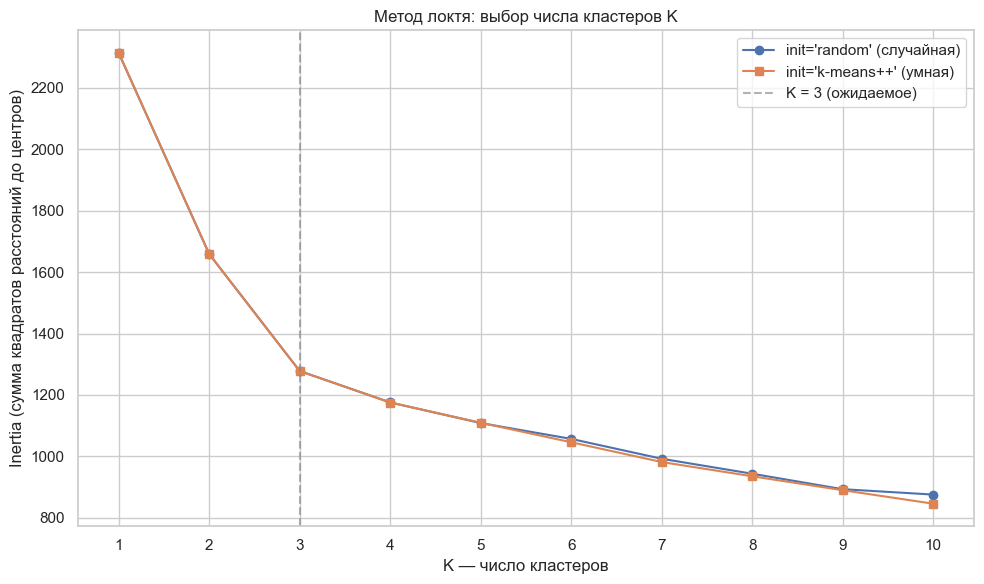

In [8]:
# 8.1 Метод локтя для двух вариантов инициализации
plt.figure(figsize=(10, 6))
plt.plot(ks, inertia_random, marker="o", label="init='random' (случайная)")
plt.plot(ks, inertia_pp,     marker="s", label="init='k-means++' (умная)")
plt.axvline(3, color="gray", linestyle="--", alpha=0.6, label="K = 3 (ожидаемое)")
plt.xlabel("K — число кластеров")
plt.ylabel("Inertia (сумма квадратов расстояний до центров)")
plt.title("Метод локтя: выбор числа кластеров K")
plt.xticks(ks)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

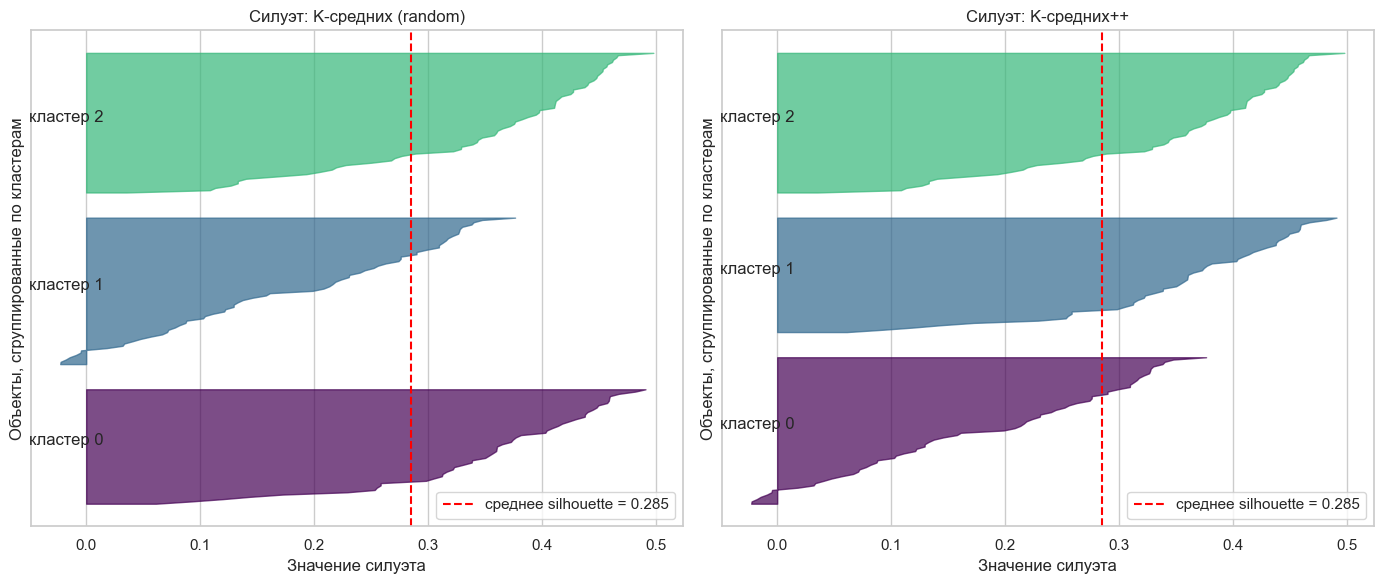

In [9]:
# 8.2 Силуэтный анализ для K=3 — сравнение двух методов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, labels) in zip(
    axes,
    [("K-средних (random)", labels_random),
     ("K-средних++",         labels_pp)],
):
    sil_vals = silhouette_samples(X_scaled, labels)
    sil_avg  = silhouette_score(X_scaled, labels)

    y_lower = 10
    for i in range(3):
        ith = np.sort(sil_vals[labels == i])
        size_i = ith.shape[0]
        y_upper = y_lower + size_i
        color = plt.cm.viridis(float(i) / 3)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, f"кластер {i}")
        y_lower = y_upper + 10

    ax.axvline(sil_avg, color="red", linestyle="--",
               label=f"среднее silhouette = {sil_avg:.3f}")
    ax.set_title(f"Силуэт: {name}")
    ax.set_xlabel("Значение силуэта")
    ax.set_ylabel("Объекты, сгруппированные по кластерам")
    ax.set_yticks([])
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

C:\Users\Таня\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\Таня\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


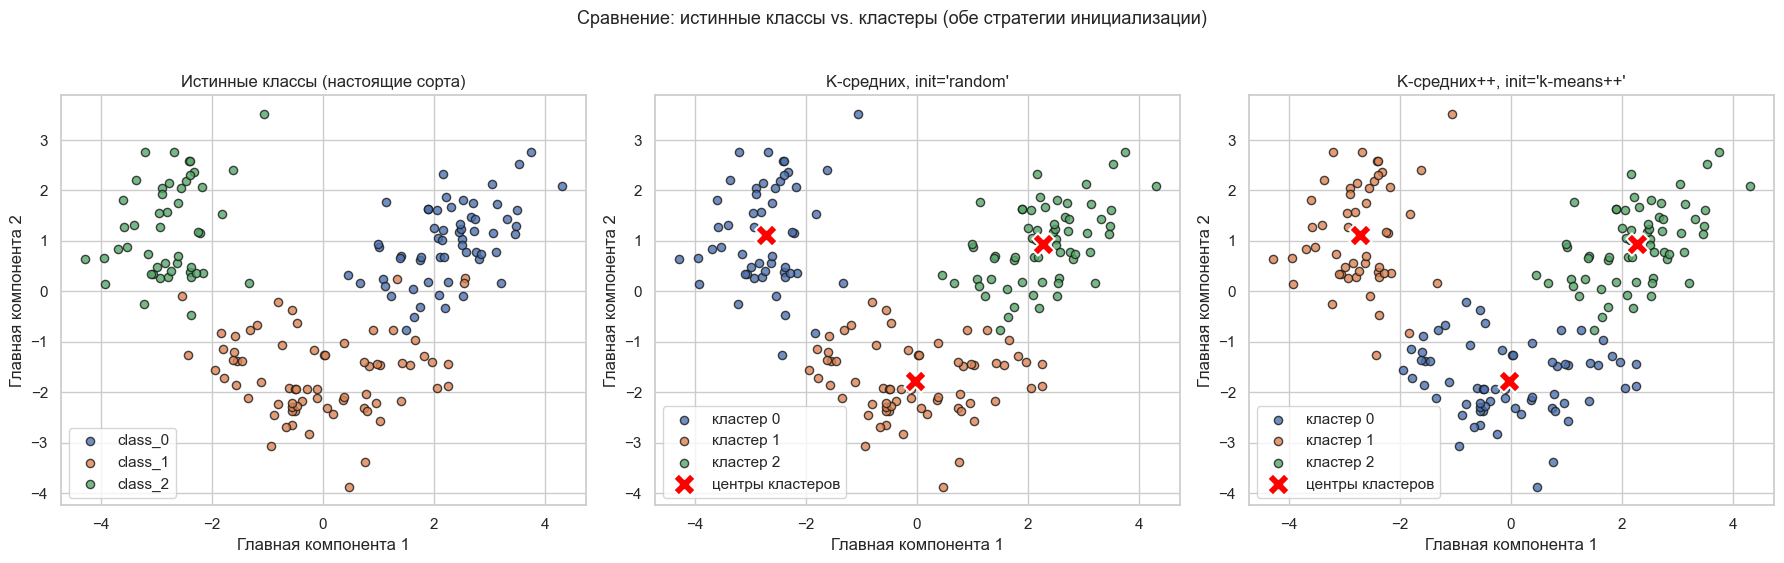

Доля объяснённой дисперсии двумя компонентами PCA: 0.554


In [10]:
# 8.3 Визуализация кластеров на плоскости PCA (2 главные компоненты)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

centers_random_pca = pca.transform(km_random.cluster_centers_)
centers_pp_pca     = pca.transform(km_pp.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Истинные классы
for i, name in enumerate(target_names):
    mask = y_true.values == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, label=name, edgecolor="k", alpha=0.8)
axes[0].set_title("Истинные классы (настоящие сорта)")
axes[0].set_xlabel("Главная компонента 1")
axes[0].set_ylabel("Главная компонента 2")
axes[0].legend()
axes[0].grid(True)

# Кластеры K-средних (random)
for i in range(3):
    mask = labels_random == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, label=f"кластер {i}",
                    edgecolor="k", alpha=0.8)
axes[1].scatter(centers_random_pca[:, 0], centers_random_pca[:, 1],
                s=260, marker="X", c="red", edgecolor="white",
                linewidth=1.5, label="центры кластеров")
axes[1].set_title("K-средних, init='random'")
axes[1].set_xlabel("Главная компонента 1")
axes[1].set_ylabel("Главная компонента 2")
axes[1].legend()
axes[1].grid(True)

# Кластеры K-средних++
for i in range(3):
    mask = labels_pp == i
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, label=f"кластер {i}",
                    edgecolor="k", alpha=0.8)
axes[2].scatter(centers_pp_pca[:, 0], centers_pp_pca[:, 1],
                s=260, marker="X", c="red", edgecolor="white",
                linewidth=1.5, label="центры кластеров")
axes[2].set_title("K-средних++, init='k-means++'")
axes[2].set_xlabel("Главная компонента 1")
axes[2].set_ylabel("Главная компонента 2")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Сравнение: истинные классы vs. кластеры (обе стратегии инициализации)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Доля объяснённой дисперсии двумя компонентами PCA: "
      f"{pca.explained_variance_ratio_.sum():.3f}")

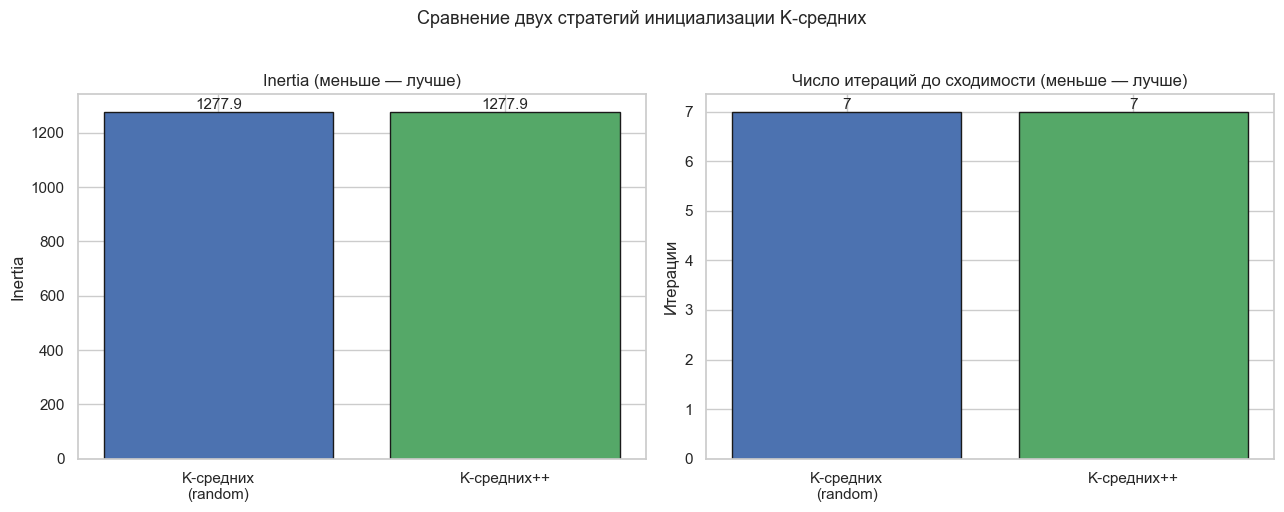

In [11]:
# 8.4 Сравнение inertia и числа итераций двух методов
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

methods = ["K-средних\n(random)", "K-средних++"]
inertias = [km_random.inertia_, km_pp.inertia_]
n_iters  = [km_random.n_iter_,  km_pp.n_iter_]
colors = ["#4C72B0", "#55A868"]

bars1 = axes[0].bar(methods, inertias, color=colors, edgecolor="k")
axes[0].set_title("Inertia (меньше — лучше)")
axes[0].set_ylabel("Inertia")
for b, v in zip(bars1, inertias):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}",
                 ha="center", va="bottom", fontsize=11)

bars2 = axes[1].bar(methods, n_iters, color=colors, edgecolor="k")
axes[1].set_title("Число итераций до сходимости (меньше — лучше)")
axes[1].set_ylabel("Итерации")
for b, v in zip(bars2, n_iters):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v}",
                 ha="center", va="bottom", fontsize=11)

plt.suptitle("Сравнение двух стратегий инициализации K-средних", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

### Короткий вывод

На датасете **Wine** обе стратегии инициализации алгоритма **K-средних** сошлись к близкому качественному решению: выделенные кластеры практически совпадают с настоящими сортами вина (высокие значения **ARI** и **NMI**). Преимущество **K-средних++** в том, что умная инициализация начальных центров делает алгоритм устойчивее: он, как правило, сходится за меньшее число итераций и реже «застревает» в плохих решениях — это особенно важно на больших и сложных датасетах, где случайная инициализация может давать заметно худший результат. **Метод локтя** на графике inertia подтверждает, что оптимальное число кластеров действительно K=3, а **силуэтный анализ** и **PCA-проекция** наглядно показывают, что найденные кластеры хорошо разделены в пространстве признаков. Обязательный предшествующий шаг — **стандартизация признаков** (`StandardScaler`), без которой расстояния в K-средних были бы искажены.